In [19]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
!pip install scikit-posthocs
import scikit_posthocs as sp
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



In [21]:
# Carica i dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FIFA22_official_data.csv')
campionati_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/squadrecampionato.csv')

# Converti in dizionario
campionati_dict = dict(zip(campionati_df['Squadra'], campionati_df['Campionato']))

# Definizione della funzione
def trova_campionato(squadra, campionati_dict):
    if not isinstance(squadra, str) or pd.isna(squadra):
        return "Non disponibile"

    if squadra in campionati_dict:
        return campionati_dict[squadra]

    squadra_norm = squadra.lower().strip()

    for team, league in campionati_dict.items():
        if team.lower().strip() == squadra_norm:
            return league

    possibili_corrispondenze = [
        team for team in campionati_dict.keys()
        if squadra_norm in team.lower() or team.lower() in squadra_norm
    ]

    if len(possibili_corrispondenze) == 1:
        return campionati_dict[possibili_corrispondenze[0]]

    return "Non disponibile"

# Applica la funzione
df['Campionato'] = df['Club'].apply(lambda x: trova_campionato(x, campionati_dict))

# Salva il risultato
df.to_csv('/content/drive/MyDrive/Colab Notebooks/FIFA22_con_campionati.csv', index=False)

print("Elaborazione completata.")

Elaborazione completata.


In [22]:
# Caricare il dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FIFA22_con_campionati.csv')  # Assicurati che il file sia nella directory corretta

In [23]:
df = df.drop(columns=list(df.columns[[0, 3, 5, 6, 7, 9, 12, 13, 15, 16, 17, 19, 20, 22, 23, 24]] )
                     + list(df.columns[27:61])
                     + list(df.columns[[62, 64]]))
display(df)

,Name,Age,Nationality,Club,Value,Wage,International Reputation,Body Type,Jersey Number,Height,Weight,Best Position,Release Clause,Campionato
0,Bruno Fernandes,26,Portugal,Manchester United,€107.5M,€250K,3.0,Unique,18.0,179cm,69kg,CAM,€206.9M,Premier League (Inghilterra)
1,L. Goretzka,26,Germany,FC Bayern München,€93M,€140K,4.0,Unique,8.0,189cm,82kg,CM,€160.4M,Bundesliga (Germania)
2,L. Suárez,34,Uruguay,Atlético de Madrid,€44.5M,€135K,5.0,Unique,9.0,182cm,83kg,ST,€91.2M,LaLiga (Spagna)
3,K. De Bruyne,30,Belgium,Manchester City,€125.5M,€350K,4.0,Unique,17.0,181cm,70kg,CM,€232.2M,Premier League (Inghilterra)
4,M. Acuña,29,Argentina,Sevilla FC,€37M,€45K,2.0,Stocky (170-185),19.0,172cm,69kg,LB,€77.7M,La Liga (Spagna)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16705,18 L. Clayton,17,England,Cheltenham Town,€100K,€1K,1.0,Normal (185+),31.0,188cm,80kg,GK,€238K,League Two (Inghilterra)
16706,�. Dobre,20,Romania,FC Academica Clinceni,€180K,€550,1.0,Normal (185+),1.0,194cm,86kg,GK,€279K,Liga I (Romania)
16707,21 Xue Qinghao,19,China PR,Shanghai Shenhua FC,€100K,€700,1.0,Lean (170-185),31.0,180cm,71kg,GK,€223K,Chinese Super League (Cina)
16708,A. Shaikh,18,India,ATK Mohun Bagan FC,€110K,€500,1.0,Normal (185+),31.0,186cm,74kg,GK,€259K,Indian Super League (India)


In [24]:
def convert_money(value):
    if pd.isna(value):  # Se il valore è NaN, lo lasciamo così
        return np.nan

    if isinstance(value, str):  # Controlliamo se è una stringa
        value = value.replace('€', '').replace(',', '').strip()  # Rimuove il simbolo € e le virgole

        try:
            if 'M' in value:
                return float(value.replace('M', '')) * 1_000_000  # Converte i milioni
            elif 'K' in value:
                return float(value.replace('K', '')) * 1_000  # Converte i migliaia
            else:
                return float(value)  # Se non ci sono suffissi, converte normalmente
        except ValueError:  # Se non può essere convertito, restituiamo NaN
            return np.nan

    return np.nan  # Se il valore non è una stringa, restituiamo NaN

# Applichiamo la funzione alle colonne
columns_to_convert = ['Value', 'Wage', 'Release Clause']
df[columns_to_convert] = df[columns_to_convert].applymap(convert_money)


<ipython-input-24-2555a036dad6>:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[columns_to_convert] = df[columns_to_convert].applymap(convert_money)


In [25]:
df = df.dropna()  # Rimuovi i valori mancanti
df['Body Type'] = df['Body Type'].astype(str).apply(lambda x: x.split('(')[0].strip()) #Sistema colonna Body Type

# Rimuove "cm" da Height e converte in interi
df['Height'] = df['Height'].str.replace('cm', '').str.strip().astype(int)

# Rimuove "kg" da Weight e converte in interi
df['Weight'] = df['Weight'].str.replace('kg', '').str.strip().astype(int)

display(df)

<ipython-input-25-5e31eabd2f20>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Body Type'] = df['Body Type'].astype(str).apply(lambda x: x.split('(')[0].strip()) #Sistema colonna Body Type
<ipython-input-25-5e31eabd2f20>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Height'] = df['Height'].str.replace('cm', '').str.strip().astype(int)
<ipython-input-25-5e31eabd2f20>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

,Name,Age,Nationality,Club,Value,Wage,International Reputation,Body Type,Jersey Number,Height,Weight,Best Position,Release Clause,Campionato
0,Bruno Fernandes,26,Portugal,Manchester United,107500000.0,250000.0,3.0,Unique,18.0,179,69,CAM,206900000.0,Premier League (Inghilterra)
1,L. Goretzka,26,Germany,FC Bayern München,93000000.0,140000.0,4.0,Unique,8.0,189,82,CM,160400000.0,Bundesliga (Germania)
2,L. Suárez,34,Uruguay,Atlético de Madrid,44500000.0,135000.0,5.0,Unique,9.0,182,83,ST,91200000.0,LaLiga (Spagna)
3,K. De Bruyne,30,Belgium,Manchester City,125500000.0,350000.0,4.0,Unique,17.0,181,70,CM,232200000.0,Premier League (Inghilterra)
4,M. Acuña,29,Argentina,Sevilla FC,37000000.0,45000.0,2.0,Stocky,19.0,172,69,LB,77700000.0,La Liga (Spagna)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16704,B. Voll,20,Germany,F.C. Hansa Rostock,375000.0,950.0,1.0,Normal,30.0,195,85,GK,656000.0,Bundesliga 3 (Germania)
16705,18 L. Clayton,17,England,Cheltenham Town,100000.0,1000.0,1.0,Normal,31.0,188,80,GK,238000.0,League Two (Inghilterra)
16706,�. Dobre,20,Romania,FC Academica Clinceni,180000.0,550.0,1.0,Normal,1.0,194,86,GK,279000.0,Liga I (Romania)
16707,21 Xue Qinghao,19,China PR,Shanghai Shenhua FC,100000.0,700.0,1.0,Lean,31.0,180,71,GK,223000.0,Chinese Super League (Cina)


📊 Statistiche generali del Wage (Salario settimanale) nei top campionati:


,Wage
count,4279.000000
mean,22110.107502
std,32795.503294
min,500.000000
25%,3000.000000
50%,10000.000000
75%,27000.000000
max,350000.000000


<ipython-input-26-5c4997e7bf42>:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_top['Wage'], shade=True, color="skyblue")


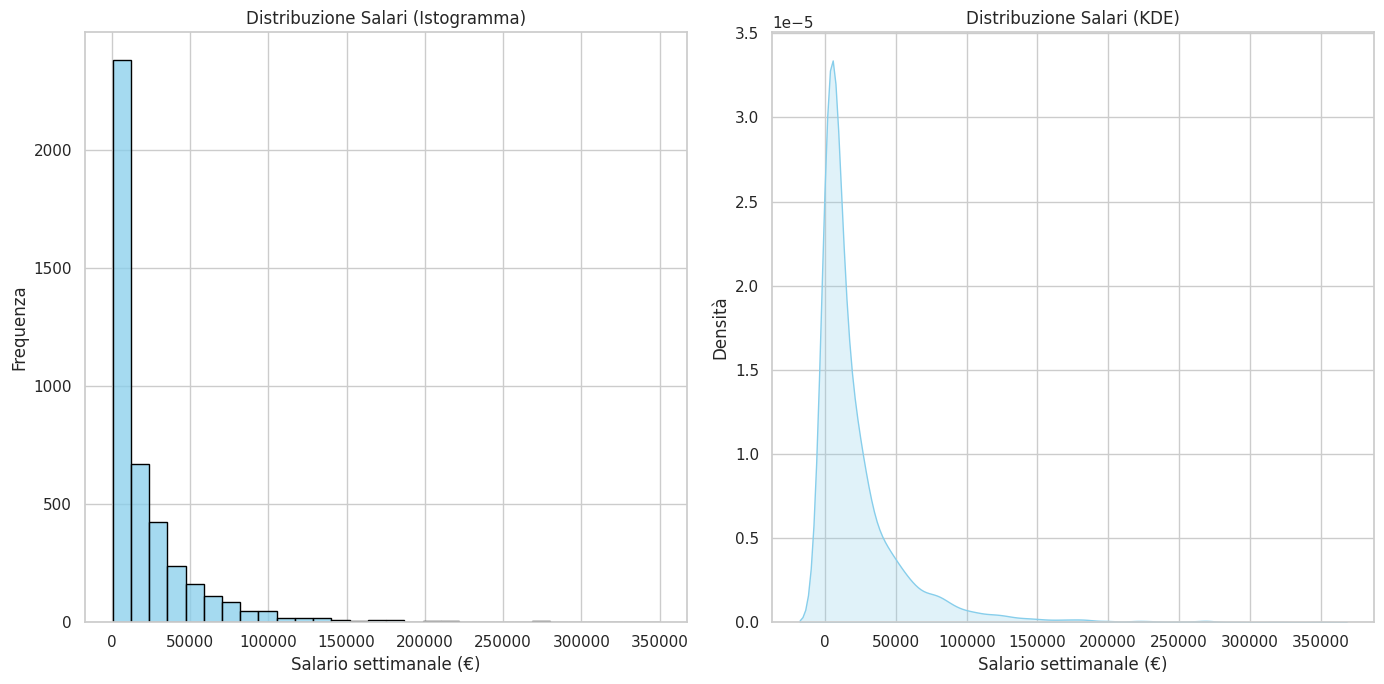


📊 Statistiche del Wage per campionato:


,count,mean,std,min,25%,50%,75%,max
Campionato,,,,,,,,
Bundesliga (Germania),538.0,24725.092937,25985.373563,500.0,7000.0,19000.0,31000.0,270000.0
Eredivisie (Paesi Bassi),438.0,5158.333333,5180.233750,500.0,2000.0,3000.0,7000.0,32000.0
LaLiga (Spagna),238.0,33691.386555,44383.338515,500.0,8000.0,21000.0,33000.0,260000.0
Ligue 1 (Francia),613.0,20386.704731,28055.152823,500.0,5000.0,14000.0,24000.0,320000.0
MLS (Stati Uniti),600.0,3529.916667,2672.927558,500.0,2000.0,3000.0,5000.0,17000.0
Premier League (Inghilterra),802.0,45180.486284,48365.849222,500.0,9000.0,32000.0,62000.0,350000.0
Primeira Liga (Portogallo),419.0,6530.906921,5102.534143,500.0,3000.0,5000.0,9000.0,30000.0
Serie A (Italia),631.0,27643.343899,27345.208571,500.0,8000.0,19000.0,40000.0,160000.0


<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


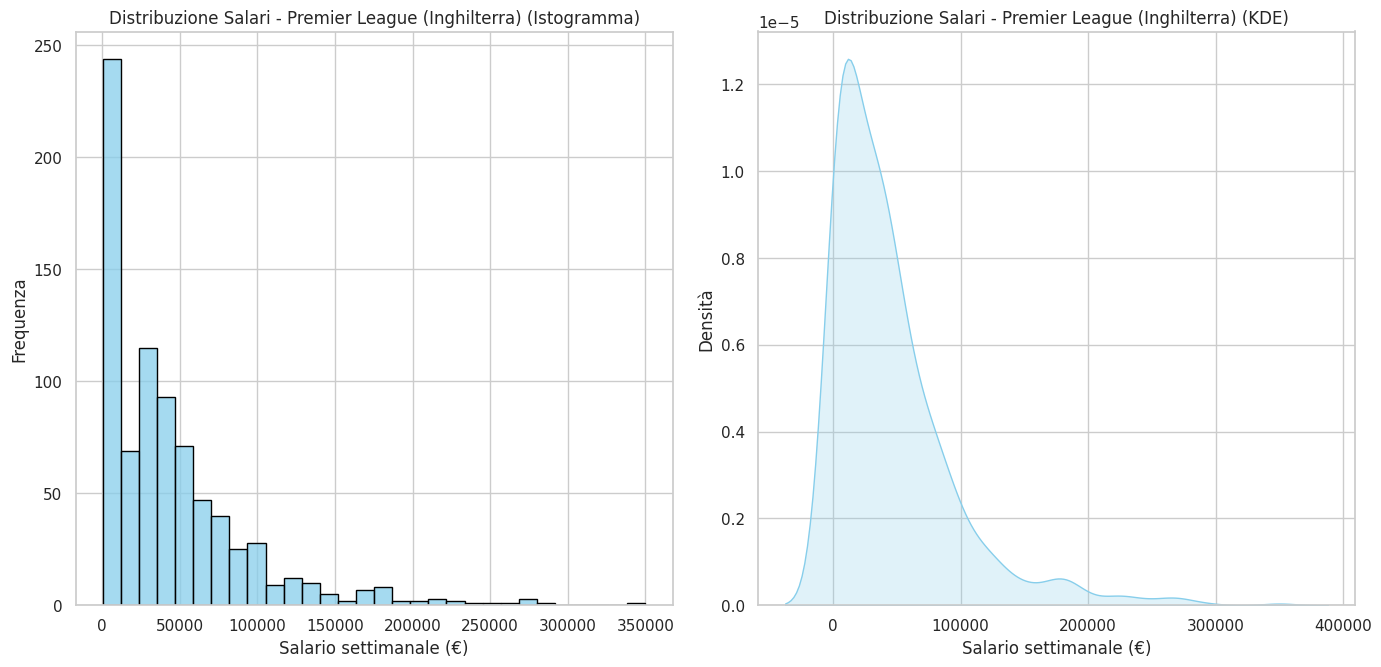

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


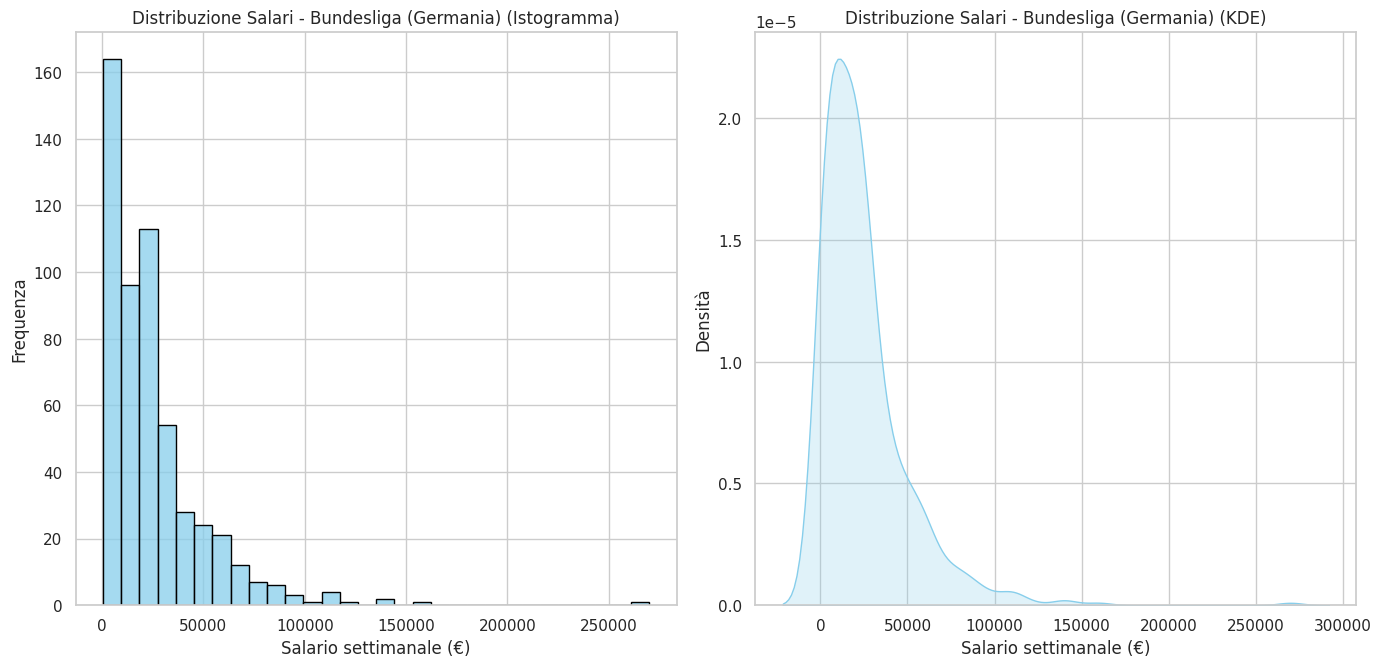

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


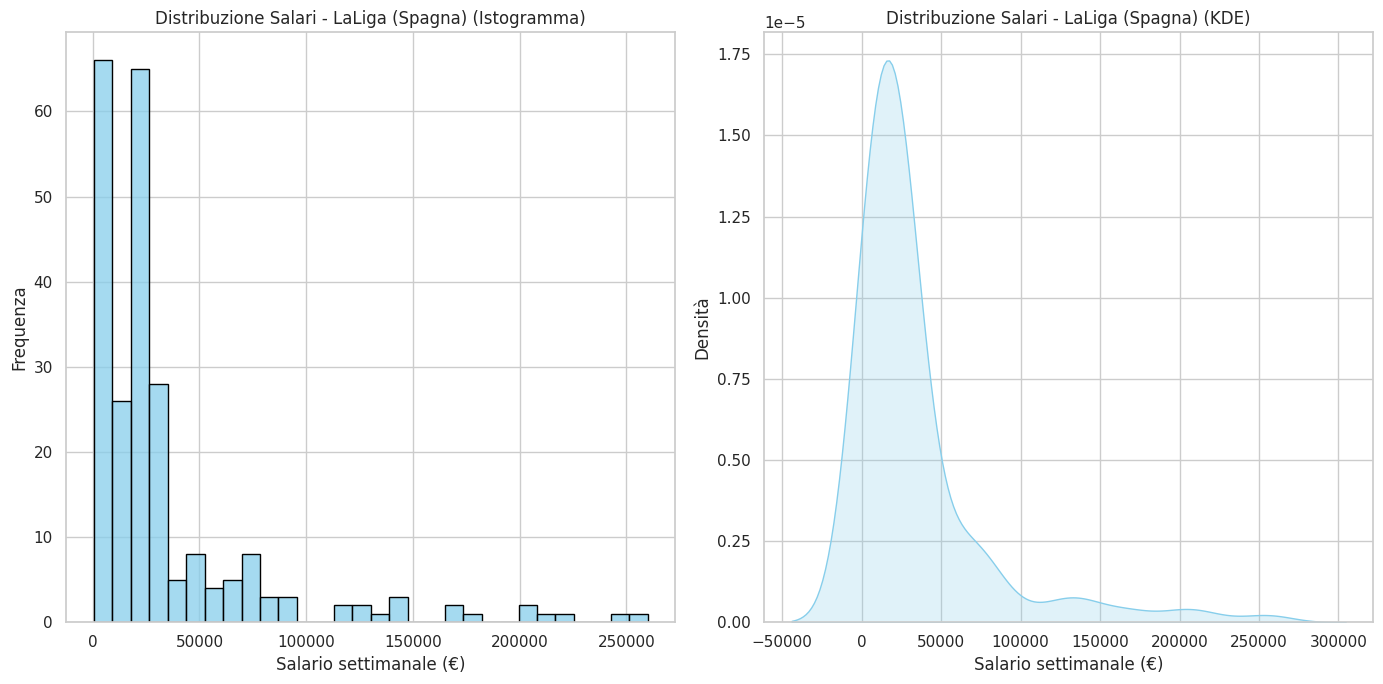

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


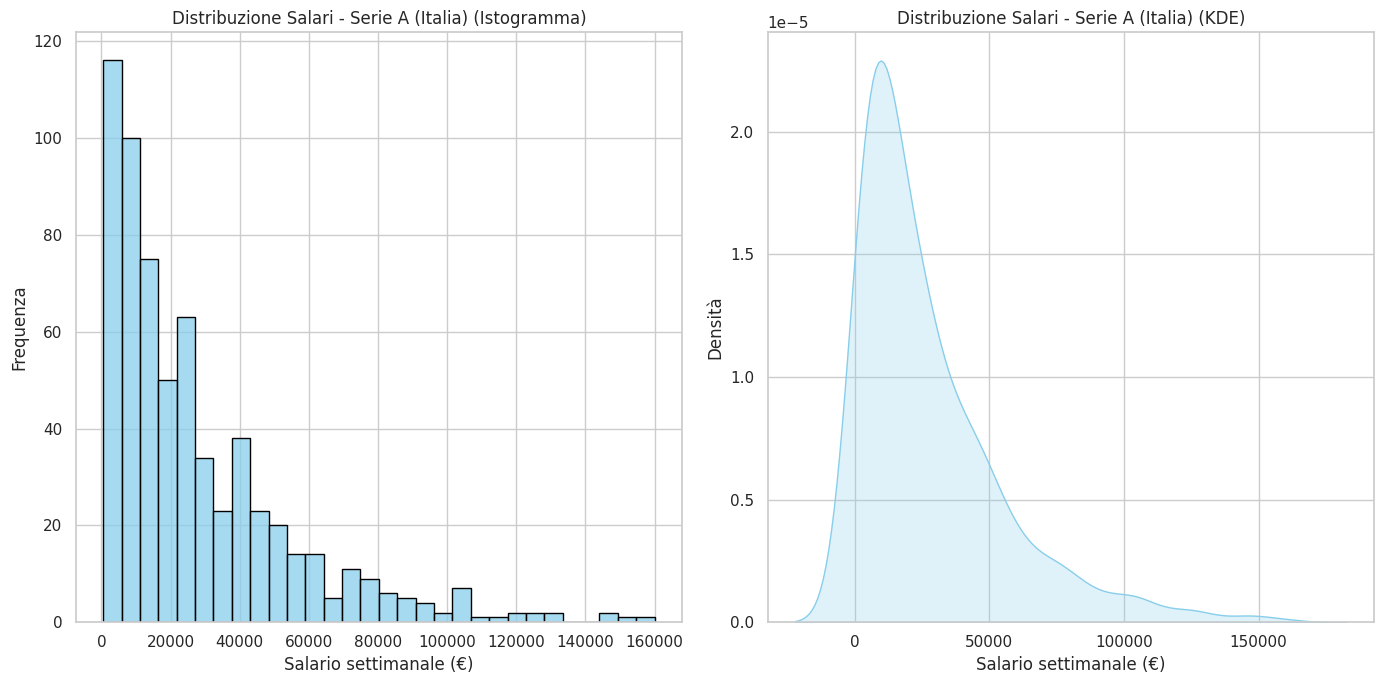

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


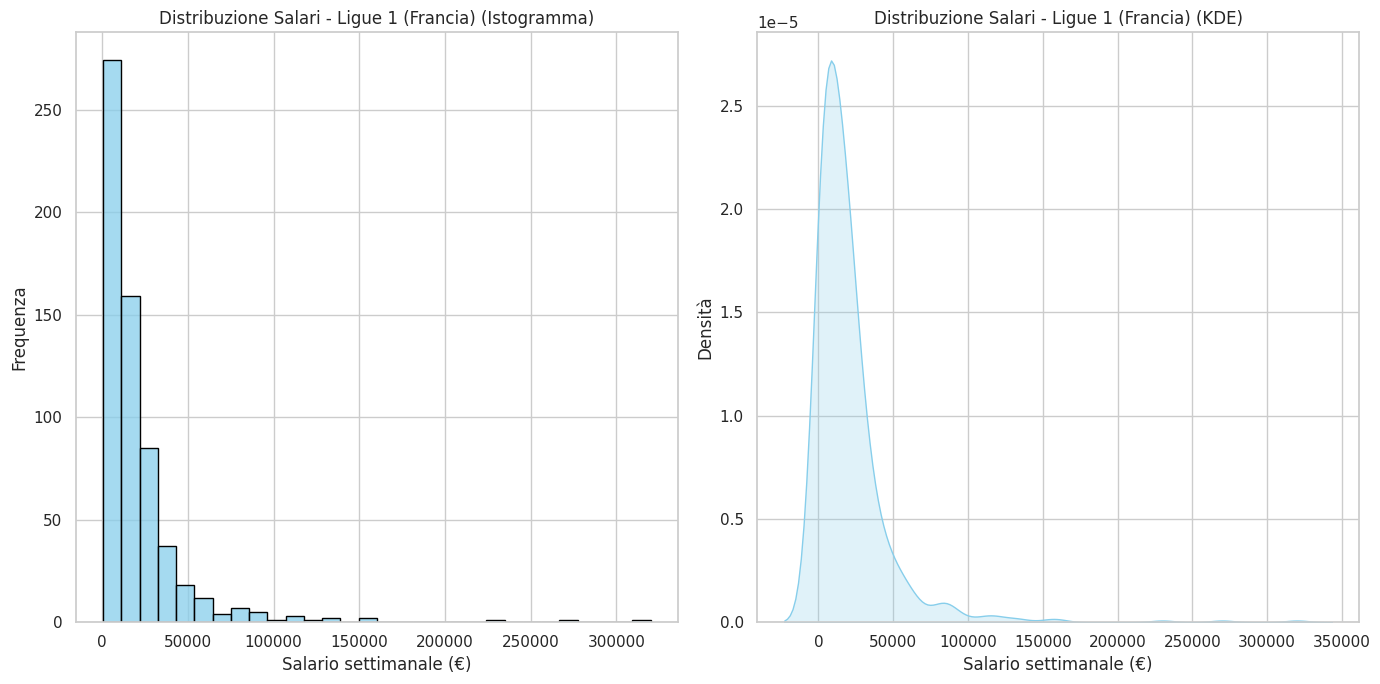

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


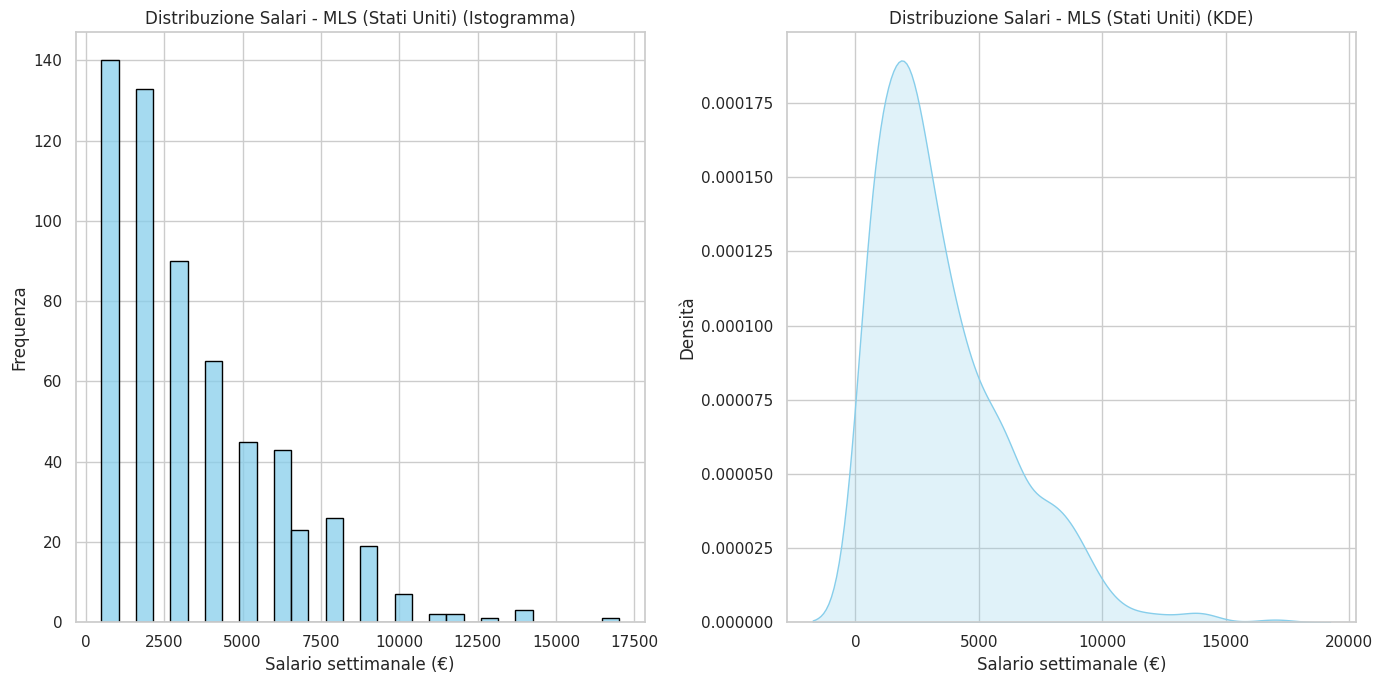

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


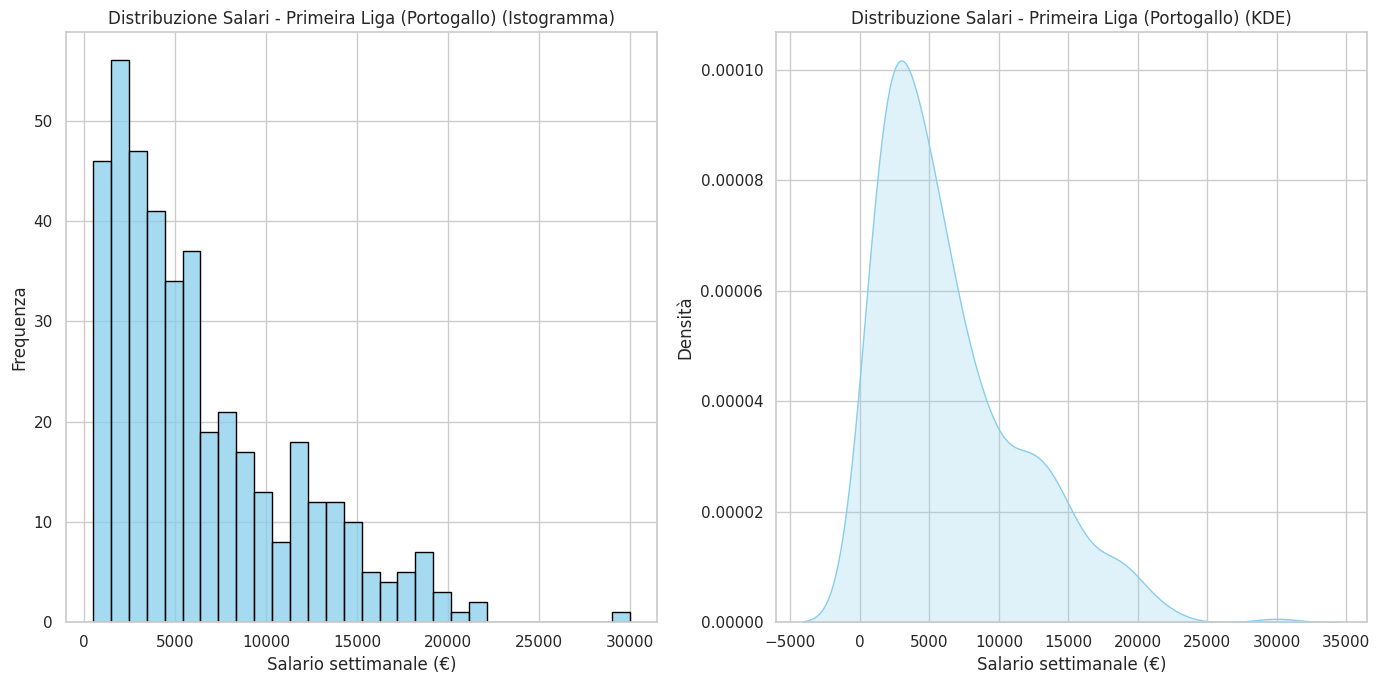

<ipython-input-26-5c4997e7bf42>:64: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")


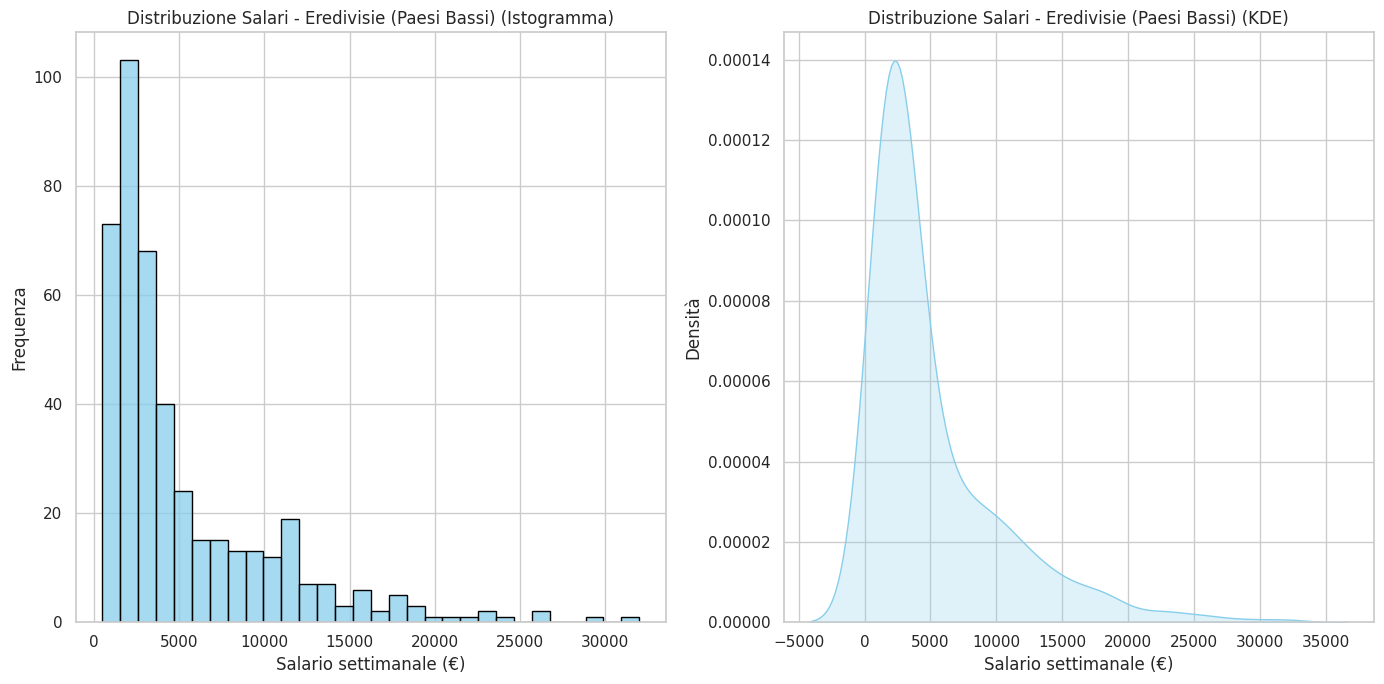

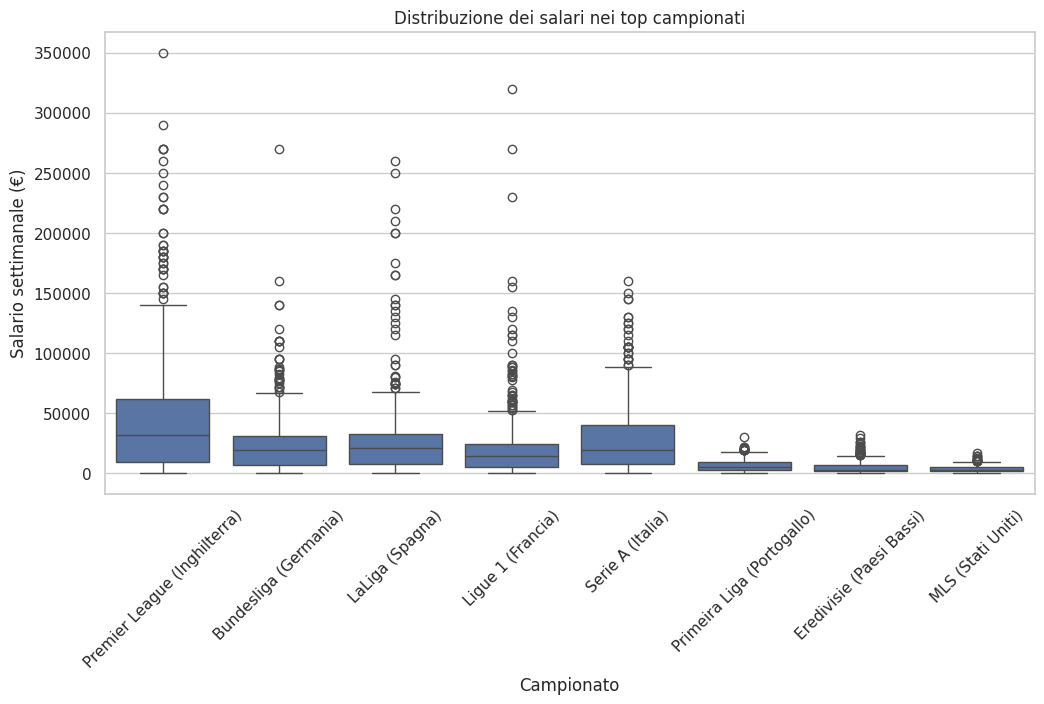

Shapiro-Wilk Test: Statistica = 0.6319565049653124, p-value = 3.8356635781703114e-70
📊 I dati NON sono distribuiti normalmente (rifiutiamo l'ipotesi nulla).
Risultato Kruskal-Wallis per Wage tra campionati:
H-statistic: 1470.784214205661, p-value: 0.0
📊 C'è una differenza significativa tra i salari nei campionati!
Matrice dei p-value per le comparazioni a coppie tra i campionati:


,Bundesliga (Germania),Eredivisie (Paesi Bassi),LaLiga (Spagna),Ligue 1 (Francia),MLS (Stati Uniti),Premier League (Inghilterra),Primeira Liga (Portogallo),Serie A (Italia)
Bundesliga (Germania),1.000000e+00,5.670036e-62,1.000000e+00,1.555363e-02,2.543782e-97,1.940096e-08,1.530051e-37,1.000000e+00
Eredivisie (Paesi Bassi),5.670036e-62,1.000000e+00,8.719055e-50,2.759301e-43,1.864744e-01,8.800212e-126,2.040801e-02,2.983514e-79
LaLiga (Spagna),1.000000e+00,8.719055e-50,1.000000e+00,3.317394e-04,2.055389e-71,1.087810e-01,3.192443e-32,1.000000e+00
Ligue 1 (Francia),1.555363e-02,2.759301e-43,3.317394e-04,1.000000e+00,5.070979e-73,5.086406e-23,5.093462e-23,2.058401e-06
MLS (Stati Uniti),2.543782e-97,1.864744e-01,2.055389e-71,5.070979e-73,1.000000e+00,9.917469e-191,8.078799e-09,3.857432e-123
Premier League (Inghilterra),1.940096e-08,8.800212e-126,1.087810e-01,5.086406e-23,9.917469e-191,1.000000e+00,5.543422e-86,1.460297e-04
Primeira Liga (Portogallo),1.530051e-37,2.040801e-02,3.192443e-32,5.093462e-23,8.078799e-09,5.543422e-86,1.000000e+00,3.804566e-50
Serie A (Italia),1.000000e+00,2.983514e-79,1.000000e+00,2.058401e-06,3.857432e-123,1.460297e-04,3.804566e-50,1.000000e+00


In [26]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

top_campionati = [
    'Premier League (Inghilterra)',
    'Bundesliga (Germania)',
    'LaLiga (Spagna)',
    'Serie A (Italia)',
    'Ligue 1 (Francia)',
    'MLS (Stati Uniti)',
    'Primeira Liga (Portogallo)',
    'Eredivisie (Paesi Bassi)',
]

df_top = df[df['Campionato'].isin(top_campionati)]

# 1. Statistiche descrittive

# 💰 Statistiche descrittive generali del salario
print("📊 Statistiche generali del Wage (Salario settimanale) nei top campionati:")
dfdescribe = df_top['Wage'].describe()
display(dfdescribe)

# Istogramma e KDE del salario per i top campionati
plt.figure(figsize=(14, 7))

# Istogramma
plt.subplot(1, 2, 1)
sns.histplot(df_top['Wage'], bins=30, kde=False, color="skyblue", edgecolor="black")
plt.title('Distribuzione Salari (Istogramma)')
plt.xlabel('Salario settimanale (€)')
plt.ylabel('Frequenza')

# KDE Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df_top['Wage'], shade=True, color="skyblue")
plt.title('Distribuzione Salari (KDE)')
plt.xlabel('Salario settimanale (€)')
plt.ylabel('Densità')

plt.tight_layout()
plt.show()

# 📊 Statistiche descrittive per ciascun campionato
print("\n📊 Statistiche del Wage per campionato:")
wage_stats_by_league = df_top.groupby('Campionato')['Wage'].describe()
display(wage_stats_by_league)

for campionato in top_campionati:
    df_campionato = df_top[df_top['Campionato'] == campionato]

    # Creazione della figura
    plt.figure(figsize=(14, 7))

    # Istogramma
    plt.subplot(1, 2, 1)
    sns.histplot(df_campionato['Wage'], bins=30, kde=False, color="skyblue", edgecolor="black")
    plt.title(f'Distribuzione Salari - {campionato} (Istogramma)')
    plt.xlabel('Salario settimanale (€)')
    plt.ylabel('Frequenza')

    # KDE Plot
    plt.subplot(1, 2, 2)
    sns.kdeplot(df_campionato['Wage'], shade=True, color="skyblue")
    plt.title(f'Distribuzione Salari - {campionato} (KDE)')
    plt.xlabel('Salario settimanale (€)')
    plt.ylabel('Densità')

    # Layout per una visualizzazione ottimale
    plt.tight_layout()
    plt.show()

# 2. Boxplot del salario per campionati selezionati
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='Campionato', y='Wage')
plt.title('Distribuzione dei salari nei top campionati')
plt.xticks(rotation=45)
plt.ylabel('Salario settimanale (€)')
plt.xlabel('Campionato')
plt.show()


#Shapiro-Wilk Test per Wage --> Distribuzione normale dei dati: forma a campana perfettamente simmetrica
stat, p_value = stats.shapiro(df_top['Wage'].dropna())

print(f"Shapiro-Wilk Test: Statistica = {stat}, p-value = {p_value}")

# Interpretazione: IPOTESI NULLA è LA DISTRIBUZIONE NORMALE
if p_value > 0.05:
    print("📊 I dati sono distribuiti normalmente (non rifiutiamo l'ipotesi nulla).")
else:
    print("📊 I dati NON sono distribuiti normalmente (rifiutiamo l'ipotesi nulla).")


# Kruskal-Wallis per confrontare i salari tra i campionati (non assume normalità)
kruskal_result = stats.kruskal(
    *[df_top[df_top['Campionato'] == campionato]['Wage'] for campionato in top_campionati]
)

# Risultato Kruskal-Wallis
print(f"Risultato Kruskal-Wallis per Wage tra campionati:\nH-statistic: {kruskal_result.statistic}, p-value: {kruskal_result.pvalue}")

# Se p-value < 0.05, c'è una differenza significativa tra i salari nei campionati
if kruskal_result.pvalue < 0.05:
    print("📊 C'è una differenza significativa tra i salari nei campionati!")
else:
    print("📊 Non ci sono differenze significative tra i salari nei campionati.")


# Esegui il test di Dunn post-hoc per verificare le differenze tra i campionati
dunn_result = sp.posthoc_dunn(df_top, val_col='Wage', group_col='Campionato', p_adjust='bonferroni')

# Visualizza la matrice dei p-value
print("Matrice dei p-value per le comparazioni a coppie tra i campionati:")
display(dunn_result)

# Interpretazione
# Se il p-value tra due campionati è inferiore a 0.05, significa che c'è una differenza significativa tra i loro salari.



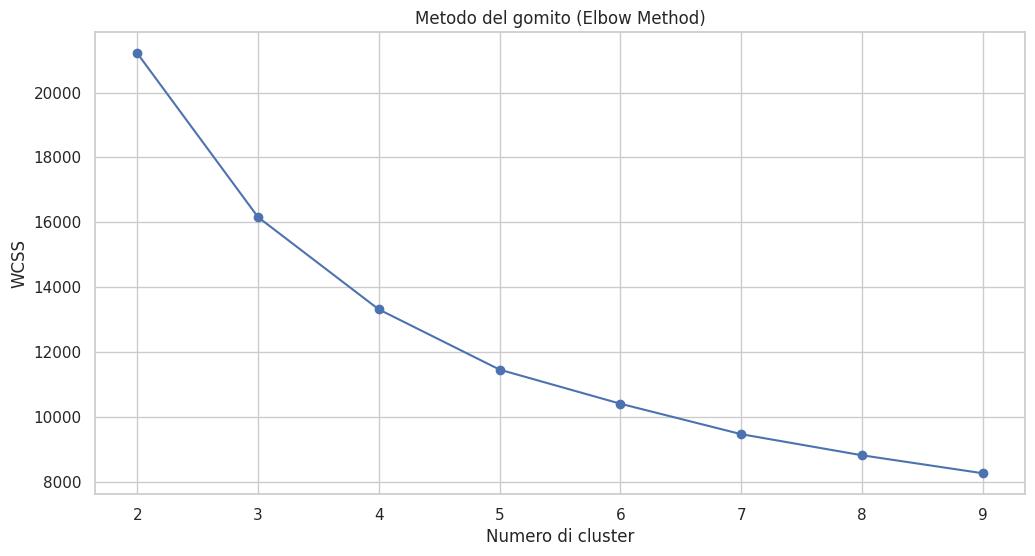

In [27]:
#RAGGRUPPIAMO GIOCATORI CON CARATTERISTICHE SIMILI E ANALIZZIAMO SE NEI CLUSTER C'è UNA DISTRIBUZIONE DIVERSA DI GIOCATORI IN BASE AL CAMPIONATO

# Seleziona le variabili numeriche per il clustering
features = ['Age', 'International Reputation', 'Height', 'Weight', 'Wage', 'Value', 'Release Clause']
df_cluster = df_top[features].dropna()

# Standardizza le variabili
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Trova il numero ottimale di cluster (Elbow method)
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 10), wcss, marker='o')
plt.title('Metodo del gomito (Elbow Method)')
plt.xlabel('Numero di cluster')
plt.ylabel('WCSS')
plt.show()

In [28]:
# Scegliamo 4 cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_top['Cluster'] = kmeans.fit_predict(X_scaled)


<ipython-input-28-5e07928cae96>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['Cluster'] = kmeans.fit_predict(X_scaled)


               Age  International Reputation      Height     Weight  \
Cluster                                                               
0        29.716612                  2.232356  183.173724  77.963084   
1        25.243658                  1.038051  187.837784  81.176903   
2        22.847359                  1.031921  176.898433  69.793964   
3        26.321168                  3.000000  181.291971  76.109489   

                  Wage         Value  Release Clause  
Cluster                                               
0         43560.260586  1.244830e+07    2.312845e+07  
1         11443.691589  3.026676e+06    5.921904e+06  
2         10277.132908  3.219129e+06    6.362216e+06  
3        143357.664234  6.518613e+07    1.240577e+08  
Cluster                           0      1      2     3
Campionato                                             
Bundesliga (Germania)         180.0  197.0  141.0  20.0
Eredivisie (Paesi Bassi)       34.0  166.0  238.0   0.0
LaLiga (Spagna)    

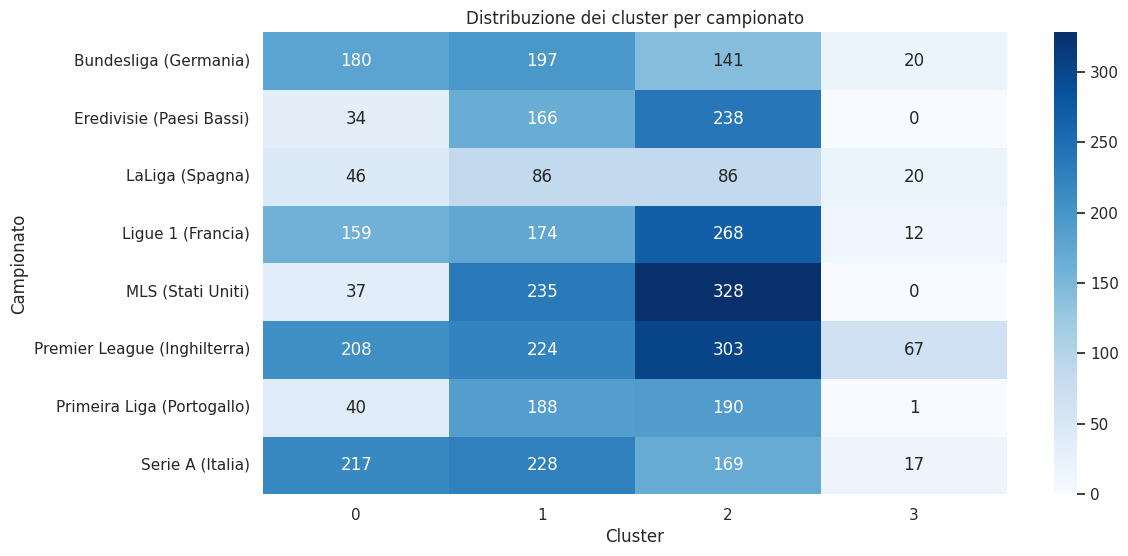

In [29]:
# Statistiche medie per ciascun cluster
cluster_summary = df_top.groupby('Cluster')[features].mean()
print(cluster_summary)

# Distribuzione dei cluster nei campionati
cluster_distribution = df_top.groupby(['Campionato', 'Cluster']).size().unstack().fillna(0)
print(cluster_distribution)

# Visualizza la distribuzione con un heatmap
sns.heatmap(cluster_distribution, annot=True, fmt='g', cmap='Blues')
plt.title('Distribuzione dei cluster per campionato')
plt.ylabel('Campionato')
plt.xlabel('Cluster')
plt.show()


,Campionato,Cluster,Wage
0,Bundesliga (Germania),0,38322.22
1,Bundesliga (Germania),1,13313.20
2,Bundesliga (Germania),2,11761.70
3,Bundesliga (Germania),3,106150.00
4,Eredivisie (Paesi Bassi),0,15676.47
5,Eredivisie (Paesi Bassi),1,4071.08
6,Eredivisie (Paesi Bassi),2,4414.08
7,LaLiga (Spagna),0,52739.13
8,LaLiga (Spagna),1,15605.23
9,LaLiga (Spagna),2,16598.84


<ipython-input-30-d38358bd4585>:15: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


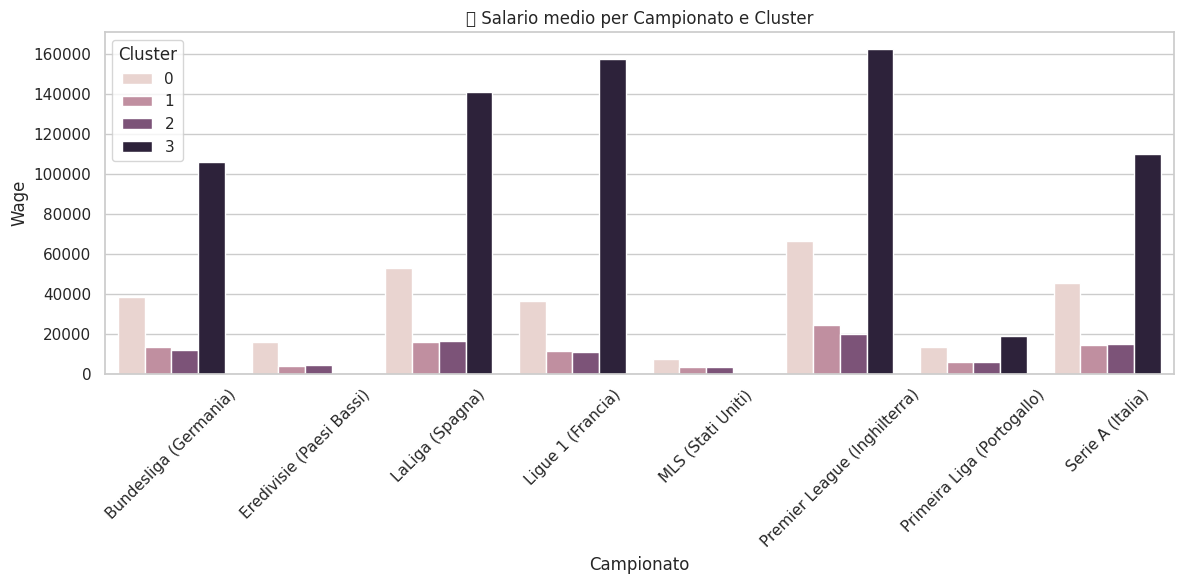

<ipython-input-30-d38358bd4585>:28: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


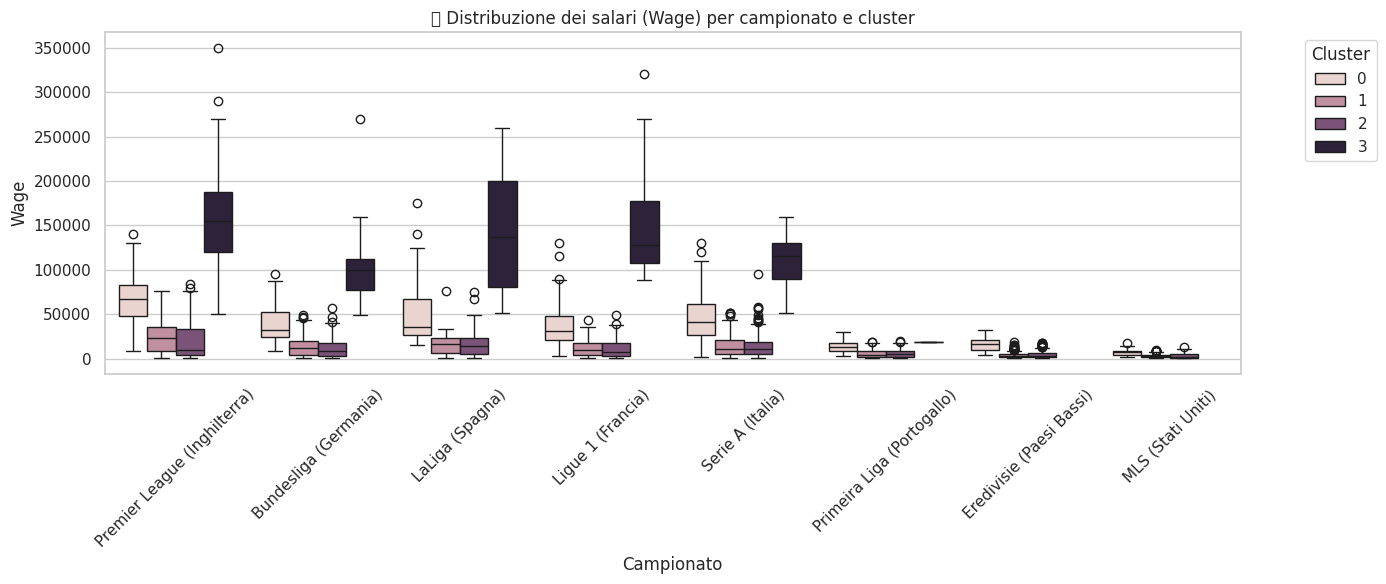

In [30]:
# CONFRONTIAMO LA METRICA DEL SALARIO PER CLUSTER E CAMPIONATO
#Confrontare il salario per cluster e campionato per capire chi spende di più, chi valorizza meglio i giocatori, e dove si concentrano gli investimenti

#calcolare le medie di salari per combinazione Cluster–Campionato:
economic_metrics = df_top.groupby(['Campionato', 'Cluster'])[['Wage']].mean().round(2)
economic_metrics = economic_metrics.reset_index()
display(economic_metrics)


plt.figure(figsize=(12,6))
sns.barplot(data=economic_metrics, x='Campionato', y='Wage', hue='Cluster')
plt.title('💰 Salario medio per Campionato e Cluster')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

#BoxPlot
#La variabilità interna (distribuzione) di salari tra giocatori
#Le differenze tra campionati all'interno dello stesso cluster,
#La presenza di outlier (giocatori fuori scala = top player 💸).

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top, x='Campionato', y='Wage', hue='Cluster')
plt.title('💰 Distribuzione dei salari (Wage) per campionato e cluster')
plt.xticks(rotation=45)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

📊 Differenze percentuali rispetto alla media di cluster:


,Cluster,Campionato,Wage
0,0,Bundesliga (Germania),-12.0
1,0,Eredivisie (Paesi Bassi),-64.0
2,0,LaLiga (Spagna),21.1
3,0,Ligue 1 (Francia),-16.7
4,0,MLS (Stati Uniti),-83.5
5,0,Premier League (Inghilterra),53.1
6,0,Primeira Liga (Portogallo),-69.0
7,0,Serie A (Italia),3.8
8,1,Bundesliga (Germania),16.3
9,1,Eredivisie (Paesi Bassi),-64.4


<ipython-input-31-be1bf891e808>:28: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


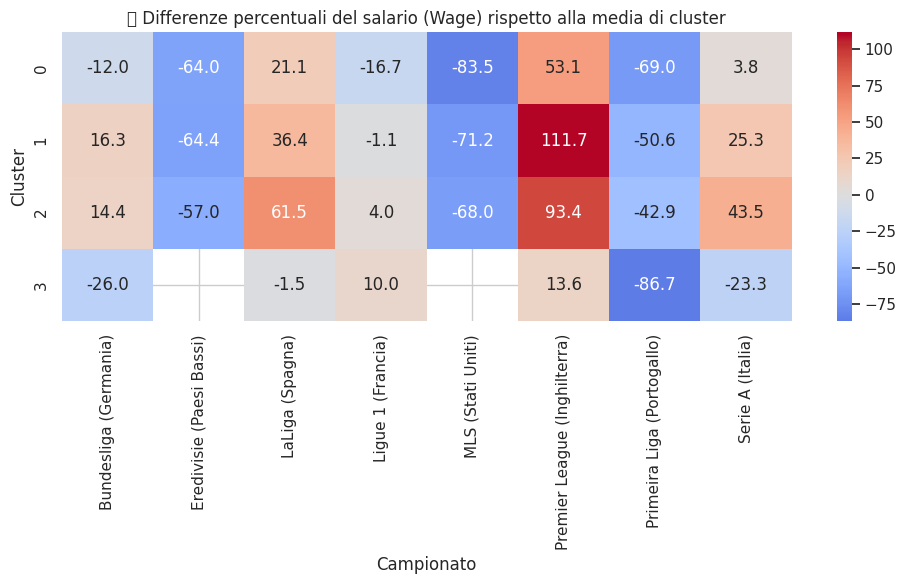

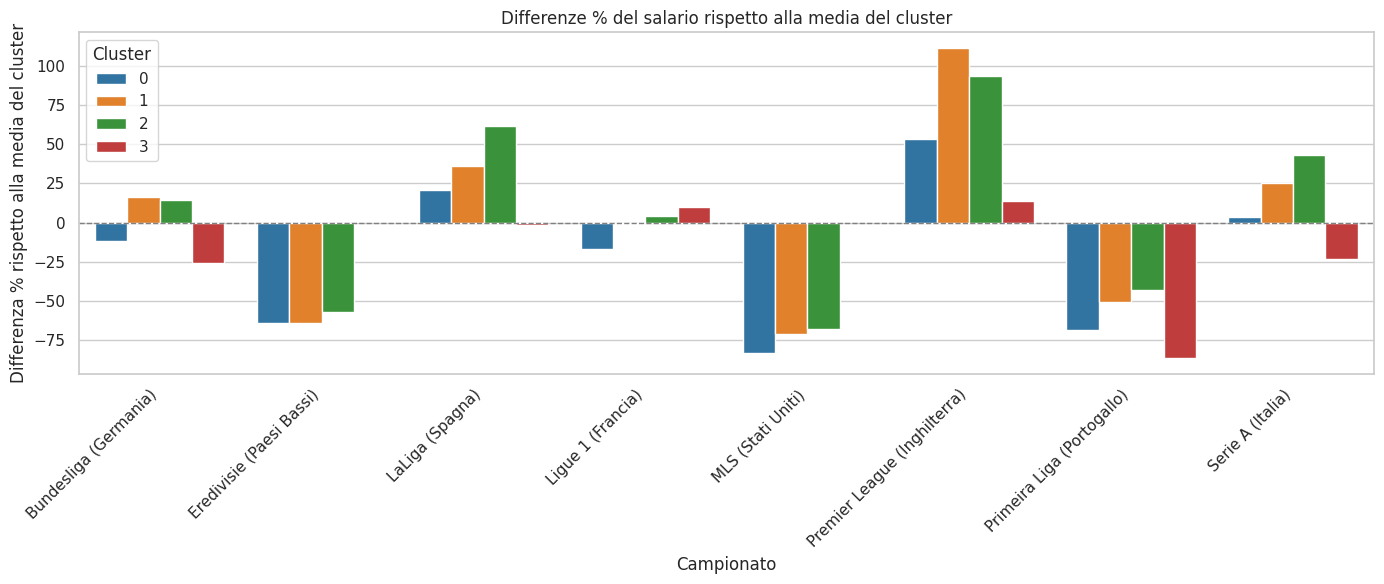

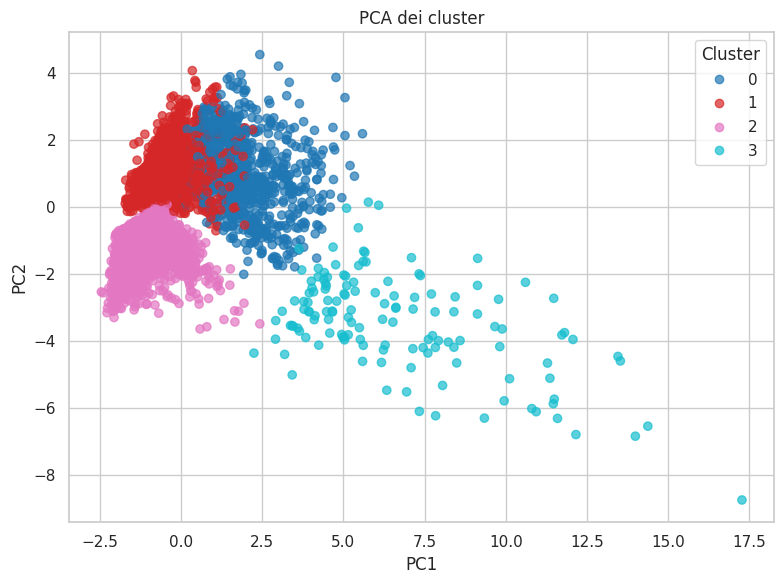

In [31]:
# Calcoliamo la media per cluster e campionato
grouped = df_top.groupby(['Cluster', 'Campionato'])[['Wage']].mean()

# Calcoliamo la media per cluster (tutti i campionati)
cluster_means = df_top.groupby('Cluster')[['Wage']].mean()

# Uniamo i due DataFrame
diff_perc = grouped.copy()

# Calcolo della differenza percentuale: ((campionato - media cluster) / media cluster) * 100
for var in ['Wage']:
    diff_perc[var] = grouped[var] / cluster_means[var] * 100 - 100  # rispetto alla media del cluster

# Pulizia per visualizzazione
diff_perc = diff_perc.reset_index().round(1)

print("📊 Differenze percentuali rispetto alla media di cluster:")
display(diff_perc)

# Pivot per heatmap
heatmap_data = diff_perc.pivot(index='Cluster', columns='Campionato', values='Wage')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='coolwarm', center=0)
plt.title('💰 Differenze percentuali del salario (Wage) rispetto alla media di cluster')
plt.ylabel('Cluster')
plt.xlabel('Campionato')
plt.tight_layout()
plt.show()

# Imposta lo stile dei grafici
sns.set(style="whitegrid")

# Dimensione figura
plt.figure(figsize=(14, 6))

# Crea un grafico a barre per ogni cluster
sns.barplot(
    data=diff_perc,
    x='Campionato',
    y='Wage',
    hue='Cluster',
    palette='tab10'
)

plt.title('Differenze % del salario rispetto alla media del cluster')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Differenza % rispetto alla media del cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Cluster')
plt.show()


# 1. Seleziona solo le colonne numeriche per la PCA
numeric_cols = df_top.select_dtypes(include='number')

# 2. Standardizzazione
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

# 3. PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

# 4. Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(components[:, 0], components[:, 1], c=df_top['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA dei cluster')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()
